**Installing dependencies**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from wordcloud import WordCloud

In [2]:
from google.colab import files
uploaded = files.upload()


Saving NLP_Law_Dataset.zip to NLP_Law_Dataset.zip


In [3]:
!pip install krippendorff

In [4]:
!pip install tensorflow

**Loading dataset**

In [5]:
!unzip /content/NLP_Law_Dataset.zip -d /content/NLP_Law


Archive:  /content/NLP_Law_Dataset.zip
  inflating: /content/NLP_Law/absence-of-certain-changes-or-events.csv  
  inflating: /content/NLP_Law/absence-of-certain-changes.csv  
  inflating: /content/NLP_Law/acceleration.csv  
  inflating: /content/NLP_Law/access-to-information.csv  
  inflating: /content/NLP_Law/access.csv  
  inflating: /content/NLP_Law/accounting-terms.csv  
  inflating: /content/NLP_Law/additional-agreements.csv  
  inflating: /content/NLP_Law/additional-documents.csv  
  inflating: /content/NLP_Law/adjustments.csv  
  inflating: /content/NLP_Law/affirmative-covenants.csv  
  inflating: /content/NLP_Law/agreement.csv  
  inflating: /content/NLP_Law/agreements.csv  
  inflating: /content/NLP_Law/amendment-and-waiver.csv  
  inflating: /content/NLP_Law/amendment-waiver.csv  
  inflating: /content/NLP_Law/amendment.csv  
  inflating: /content/NLP_Law/amendments-and-waivers.csv  
  inflating: /content/NLP_Law/amendments-etc.csv  
  inflating: /content/NLP_Law/amendments-w

In [6]:
!ls /content/NLP_Law


absence-of-certain-changes.csv
absence-of-certain-changes-or-events.csv
acceleration.csv
access.csv
access-to-information.csv
accounting-terms.csv
additional-agreements.csv
additional-documents.csv
adjustments.csv
affirmative-covenants.csv
agreement.csv
agreements.csv
amendment-and-waiver.csv
amendment.csv
amendments-and-waivers.csv
amendments.csv
amendments-etc.csv
amendments-waivers.csv
amendment-waiver.csv
applicable-law.csv
application-of-proceeds.csv
appointment.csv
approvals.csv
arbitration.csv
assignability.csv
assignment.csv
assignments.csv
attorneys-fees.csv
authority.csv
authorization.csv
auto_renewal.csv
background.csv
bank-accounts.csv
bankruptcy.csv
base-salary.csv
benefits.csv
bereavement-leave.csv
binding-effect.csv
bonus.csv
books-and-records.csv
brokerage.csv
brokers.csv
cancellation.csv
capitalization.csv
capitalized-terms.csv
captions.csv
cause.csv
certain-defined-terms.csv
certain-definitions.csv
certificates.csv
change-in-control.csv
change-of-control.csv
choice-of

In [7]:
sns.set(style="whitegrid", palette="pastel")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

data_path = "/content/NLP_Law"

In [8]:
files = [
    "acceleration.csv",
    "confidentiality.csv",
    "termination.csv",
    "payment.csv",
    "governing-law.csv",
    "indemnification.csv",
    "force-majeure.csv",
    "licenses.csv",
    "voting.csv",
    "litigation.csv",
    "waiver.csv",
    "vacation.csv",
    "security-deposit.csv",
    "bonus.csv",
    "rent.csv",
    "judgments.csv",
    "survival.csv",
    "non-discrimination.csv",
    "power-of-attorney.csv",
    "employee-benefits.csv"

]

In [9]:

datasets = {}
for file in files:
    name = file.replace(".csv", "").replace("-", "_")
    datasets[name] = pd.read_csv(os.path.join(data_path, file))

for name, df in datasets.items():
    print(f"{name}")
    print(df.head(), "\n")


acceleration
                                         clause_text   clause_type
0  Acceleration. On and at any time after the occ...  acceleration
1  Acceleration. (a) If an Event of Default with ...  acceleration
2  Acceleration. If an Event of Default (other th...  acceleration
3  Acceleration. If an Event of Default with resp...  acceleration
4  Acceleration. If any Default described in Sect...  acceleration 

confidentiality
                                         clause_text      clause_type
0  Confidentiality. The parties hereto agree that...  confidentiality
1  Confidentiality. The Parties acknowledge that ...  confidentiality
2  Confidentiality. (a) Subject to Section 7.15(c...  confidentiality
3  Confidentiality. The Executive recognizes and ...  confidentiality
4  Confidentiality. Subject to the duties of the ...  confidentiality 

termination
                                         clause_text  clause_type
0  Termination. This Agreement may be terminated ...  termination
1

**Visualising datasets**

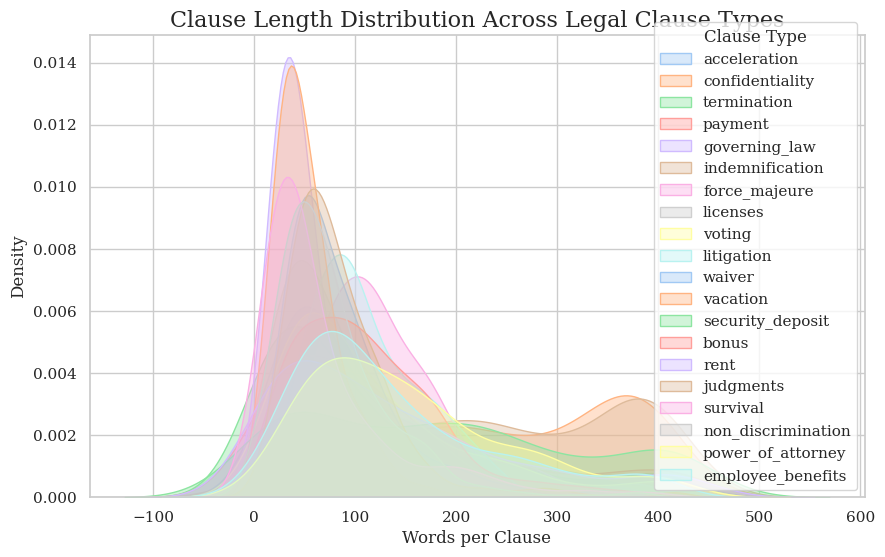

In [10]:
plt.figure(figsize=(10,6))
for name, df in datasets.items():
    df["clause_length"] = df["clause_text"].apply(lambda x: len(str(x).split()))
    sns.kdeplot(df["clause_length"], label=name, fill=True, alpha=0.4)
plt.title("Clause Length Distribution Across Legal Clause Types")
plt.xlabel("Words per Clause")
plt.ylabel("Density")
plt.legend(title="Clause Type")
plt.show()


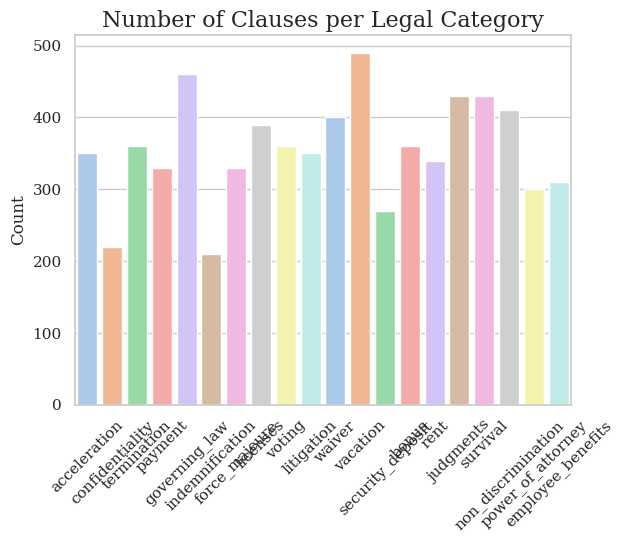

In [11]:
counts = {name: len(df) for name, df in datasets.items()}
sns.barplot(x=list(counts.keys()), y=list(counts.values()), hue=list(counts.keys()),
            palette="pastel", legend=False)
plt.title("Number of Clauses per Legal Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [12]:
colormaps = {
    "acceleration": "Blues",
    "confidentiality": "Greens",
    "termination": "Oranges",
    "payment": "Reds",
    "governing_law": "Purples",
    "indemnification": "pink_r",
    "force_majeure": "cool",
    "licenses": "Set3",
    "voting": "Pastel1",
    "litigation": "Pastel2",
    "waiver": "Wistia",
    "vacation": "spring",
    "security_deposit": "summer",
    "rent": "autumn",
    "judgments": "Pastel2_r",
    "survival": "Pastel1_r",
    "non_discrimination": "Pastel2_r",
    "power_of_attorney": "pink_r",
    "employee_benefits": "coolwarm"
}


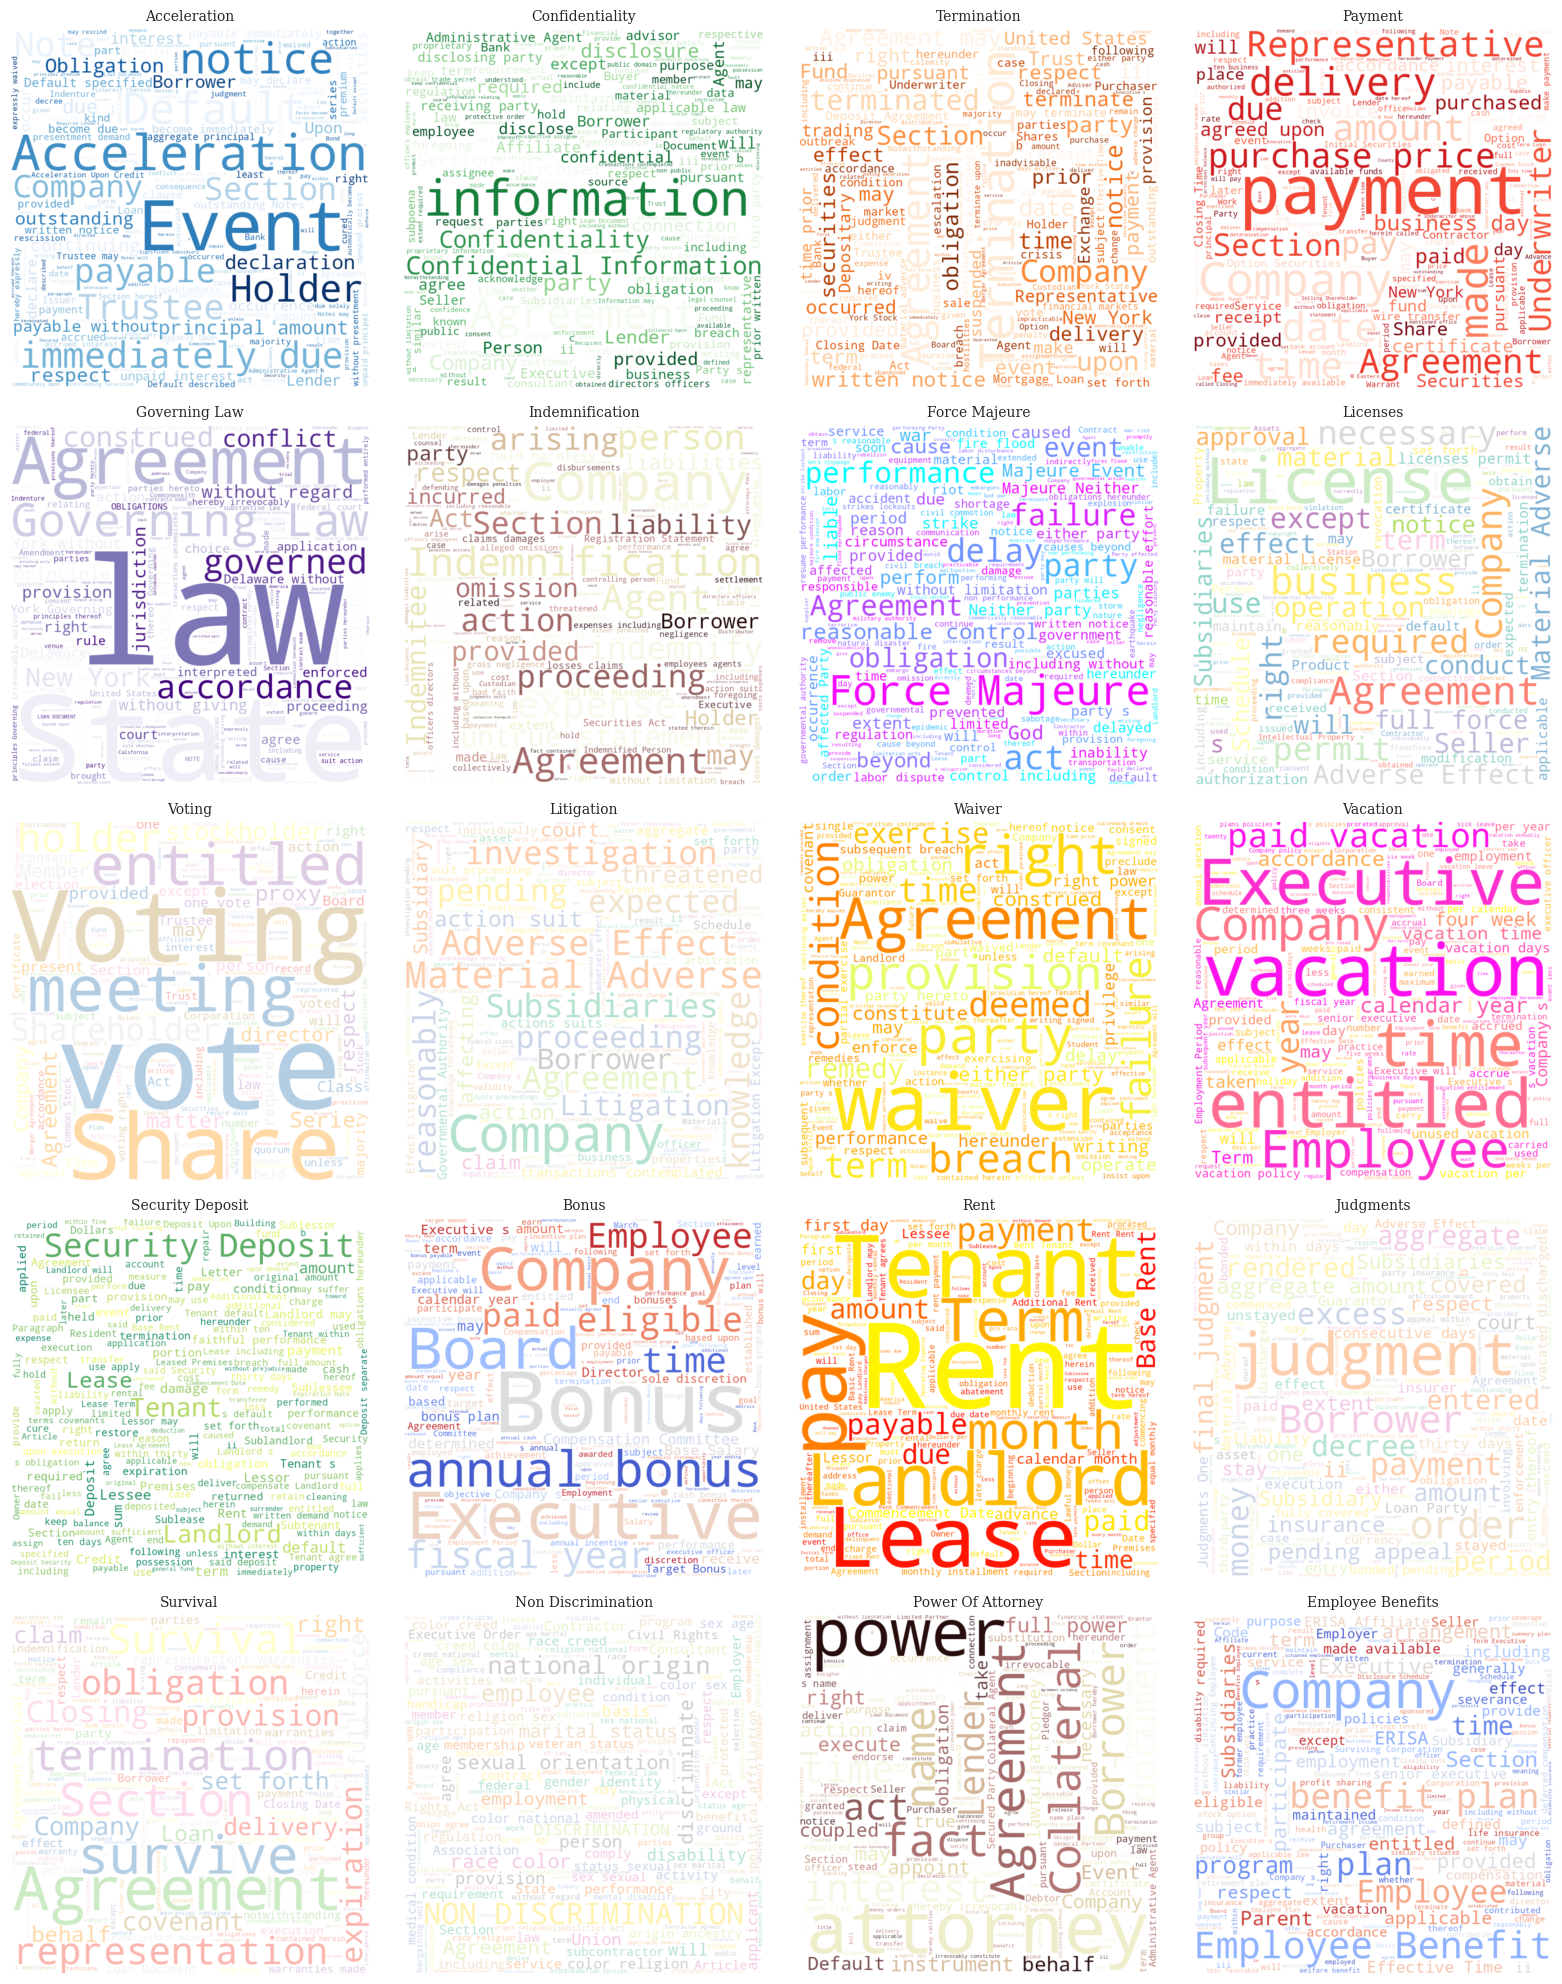

In [13]:
import math

n = len(datasets)
max_cols = 4
rows = math.ceil(n / max_cols)
cols = min(n, max_cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten()
for i, (name, df) in enumerate(datasets.items()):
    text = " ".join(str(t) for t in df["clause_text"])
    cmap = colormaps.get(name, "coolwarm")
    wc = WordCloud(width=800, height=800, background_color="white", colormap=cmap).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis("off")
    axes[i].set_title(name.replace("_"," ").title(), fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [14]:
all_clauses = []

for name, df in datasets.items():
    all_clauses.extend(df["clause_text"].astype(str).tolist())
total_clauses = len(all_clauses)
print(f"Total number of clauses across all datasets: {total_clauses}")


Total number of clauses across all datasets: 7100


**Examining dataset**

In [15]:
import pandas as pd

df_details = []

for name, df in datasets.items():
    num_clauses = df.shape[0]
    missing_values = df['clause_text'].isna().sum()
    avg_length = df['clause_text'].dropna().apply(lambda x: len(str(x).split())).mean()
    max_length = df['clause_text'].dropna().apply(lambda x: len(str(x).split())).max()
    min_length = df['clause_text'].dropna().apply(lambda x: len(str(x).split())).min()

    df_details.append({
        'clause_category': name,
        'num_clauses': num_clauses,
        'missing_values': missing_values,
        'avg_length_words': round(avg_length, 2),
        'max_length_words': max_length,
        'min_length_words': min_length
    })
summary = pd.DataFrame(df_details)



In [16]:
summary

,clause_category,num_clauses,missing_values,avg_length_words,max_length_words,min_length_words
0,acceleration,350,0,119.86,437,4
1,confidentiality,220,0,242.92,417,7
2,termination,360,0,113.63,427,3
3,payment,330,0,135.94,445,2
4,governing_law,460,0,59.52,380,9
5,indemnification,210,0,248.45,419,5
6,force_majeure,330,0,133.45,419,12
7,licenses,390,0,95.11,408,3
8,voting,360,0,119.30,429,2
9,litigation,350,0,114.81,396,16


**Pre-processing**

In [17]:
import re

def remove_html_and_urls(text):
    html_pattern = re.compile(r'<.*?>')
    url_pattern = re.compile(r'http[s]?://\S+|www\.\S+')

    found = html_pattern.search(text) or url_pattern.search(text)
    if found:
        print("HTML or URL found and removed.")

    text = re.sub(html_pattern, '', text)
    text = re.sub(url_pattern, '', text)

    return text

for name, df in datasets.items():
    df['clean_text'] = df['clause_text'].apply(remove_html_and_urls)
    count = df['clause_text'].apply(lambda x: bool(re.search(r'<.*?>|http[s]?://\S+|www\.\S+', x))).sum()
    if count > 0:
        print(f"{count} clauses in {name} contained HTML/URLs and were removed")


HTML or URL found and removed.
HTML or URL found and removed.
HTML or URL found and removed.
HTML or URL found and removed.
4 clauses in licenses contained HTML/URLs and were removed
HTML or URL found and removed.
1 clauses in security_deposit contained HTML/URLs and were removed
HTML or URL found and removed.
1 clauses in rent contained HTML/URLs and were removed
HTML or URL found and removed.
1 clauses in non_discrimination contained HTML/URLs and were removed


In [18]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

for name, df in datasets.items():
    df['clean_text'] = df['clean_text'].apply(normalize_text)


In [19]:
def remove_noise(text):
    text = re.sub(r'[^a-zA-Z0-9\s;:]', '', text)
    return text

for name, df in datasets.items():
    df['clean_text'] = df['clean_text'].apply(remove_noise)


In [20]:
def tokenize_text(text):
    return text.split()




In [21]:

for name, df in datasets.items():
    df['tokens'] = df['clean_text'].apply(tokenize_text)


In [22]:
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]


[nltk_data] Downloading package wordnet to /root/nltk_data...


In [23]:

for name, df in datasets.items():
    df['tokens_lemmatized'] = df['tokens'].apply(lemmatize_tokens)

In [24]:
!pip install tensorflow

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer

all_clauses = []
for df in datasets.values():
    all_clauses.extend([' '.join(tokens) for tokens in df['tokens_lemmatized']])

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(all_clauses)
vocab_size = len(tokenizer.word_index) + 1


In [26]:
for name, df in datasets.items():
    df['seq'] = tokenizer.texts_to_sequences([' '.join(tokens) for tokens in df['tokens_lemmatized']])


In [27]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(len(seq) for df in datasets.values() for seq in df['seq'])
for name, df in datasets.items():
    df['seq_padded'] = pad_sequences(df['seq'], maxlen=max_len, padding='post').tolist()


In [28]:
df = datasets["acceleration"]
print("Original clause text:\n", df['clause_text'].iloc[0])
print("\nLemmatized tokens:\n", df['tokens_lemmatized'].iloc[0])
print("\nInteger sequence:\n", df['seq'].iloc[0])
print("\nPadded sequence:\n", df['seq_padded'].iloc[0])


Original clause text:
 Acceleration. On and at any time after the occurrence of an Event of Default which is continuing the Agent may, and shall if so directed by the Majority Lenders, by notice to the Borrower:

Lemmatized tokens:
 ['acceleration', 'on', 'and', 'at', 'any', 'time', 'after', 'the', 'occurrence', 'of', 'an', 'event', 'of', 'default', 'which', 'is', 'continuing', 'the', 'agent', 'may', 'and', 'shall', 'if', 'so', 'directed', 'by', 'the', 'majority', 'lender', 'by', 'notice', 'to', 'the', 'borrower:']

Integer sequence:
 [186, 26, 6, 32, 7, 29, 91, 2, 344, 3, 39, 53, 3, 78, 27, 22, 357, 2, 63, 28, 6, 10, 35, 173, 1145, 12, 2, 512, 104, 12, 62, 5, 2, 67]

Padded sequence:
 [186, 26, 6, 32, 7, 29, 91, 2, 344, 3, 39, 53, 3, 78, 27, 22, 357, 2, 63, 28, 6, 10, 35, 173, 1145, 12, 2, 512, 104, 12, 62, 5, 2, 67, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [43]:
import random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

rows = []
for name, df in datasets.items():
    for idx, row in df.iterrows():
        rows.append((row['seq_padded'], name))

clauses, labels = zip(*rows)
clauses = np.array(clauses)
labels = np.array(labels)


In [44]:

label_to_indices = {}
for i, lab in enumerate(labels):
    label_to_indices.setdefault(lab, []).append(i)

pairs_a = []
pairs_b = []
pair_labels = []

n_neg_per_pos = 1
sample_limit = len(clauses)


In [45]:

for i in range(sample_limit):
    a = clauses[i]
    lab = labels[i]
    pos_choices = label_to_indices[lab].copy()
    pos_choices = [p for p in pos_choices if p != i]
    if pos_choices:
        j = random.choice(pos_choices)
        pairs_a.append(a)
        pairs_b.append(clauses[j])
        pair_labels.append(1)
    for _ in range(n_neg_per_pos):
        neg_lab = random.choice([l for l in label_to_indices.keys() if l != lab])
        j = random.choice(label_to_indices[neg_lab])
        pairs_a.append(a)
        pairs_b.append(clauses[j])
        pair_labels.append(0)


In [46]:

pairs_a = np.array(pairs_a)
pairs_b = np.array(pairs_b)
pair_labels = np.array(pair_labels)

x1_train, x1_val, x2_train, x2_val, y_train, y_val = train_test_split(
    pairs_a, pairs_b, pair_labels, test_size=0.2, random_state=42, stratify=pair_labels)

batch_size = 64

train_ds = tf.data.Dataset.from_tensor_slices(((x1_train, x2_train), y_train)).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices(((x1_val, x2_val), y_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [47]:
import tensorflow as tf
from tensorflow.keras import layers, Model

vocab_size = max(int(np.max(clauses)), 1) + 1
embedding_dim = 128
seq_len = clauses.shape[1]

def make_encoder():
    inp = layers.Input(shape=(seq_len,), dtype='int32')
    x = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=seq_len, mask_zero=True)(inp)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
    x = layers.Bidirectional(layers.LSTM(32, dropout=0.2, recurrent_dropout=0.1))(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    return Model(inp, x)

encoder = make_encoder()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [48]:
a_in = layers.Input(shape=(seq_len,), dtype='int32')
b_in = layers.Input(shape=(seq_len,), dtype='int32')

a_vec = encoder(a_in)
b_vec = encoder(b_in)

diff = layers.Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([a_vec, b_vec])
merged = layers.Dense(64, activation='relu')(diff)
merged = layers.Dropout(0.3)(merged)
out = layers.Dense(1, activation='sigmoid')(merged)

siamese_model = Model([a_in, b_in], out)
siamese_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
siamese_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 447)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 447)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 64)        │  1,423,424 │ input_layer_2[0]… │
│ (Functional)        │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 64)        │          0 │ functional_1[0][… │
│                     │                   │            │ functional_1[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      4,160 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,427,649 (5.45 MB)

 Trainable params: 1,427,649 (5.45 MB)

 Non-trainable params: 0 (0.00 B)

**Training**

In [49]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
ckpt = ModelCheckpoint('best_siamese.h5', monitor='val_loss', save_best_only=True, verbose=1)

history = siamese_model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[es, ckpt], verbose=1)


Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.5391 - loss: 0.6700 
Epoch 1: val_loss improved from inf to 0.44821, saving model to best_siamese.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 2260s 13s/step - accuracy: 0.5395 - loss: 0.6697 - val_accuracy: 0.8081 - val_loss: 0.4482
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7861 - loss: 0.4492 
Epoch 2: val_loss improved from 0.44821 to 0.29140, saving model to best_siamese.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 2232s 13s/step - accuracy: 0.7862 - loss: 0.4490 - val_accuracy: 0.9278 - val_loss: 0.2914
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8402 - loss: 0.3683 
Epoch 3: val_loss improved from 0.29140 to 0.22572, saving model to best_siamese.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 2231s 13s/step - accuracy: 0.8403 - loss: 0.3682 - val_accuracy: 0.9366 - val_loss: 0.2257
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8723 - loss: 0.3098 
Epoch 4: val_loss improved from 0.22572 to 0.20707, saving model to best_siamese.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 2268s 13s/step - accuracy: 0.8723 - loss: 0.3098 - val_accuracy: 0.9243 - val_loss: 0.2071
Epoch 5/20
 83/178 ━━━━━━━━━━━━━━━━━━━━ 18:58 12s/step - accuracy: 0.8835 - loss: 0.2751

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
palette = sns.color_palette('pastel')

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss', color=palette[0], linewidth=2)
plt.plot(history.history['val_loss'], label='val loss', color=palette[1], linewidth=2)
plt.title('loss over epochs', fontsize=12)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

In [ ]:


plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc', color=palette[2], linewidth=2)
plt.plot(history.history['val_accuracy'], label='val acc', color=palette[3], linewidth=2)
plt.title('accuracy over epochs', fontsize=12)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support

best = tf.keras.models.load_model('best_siamese.h5')

x1_test = x1_val
x2_test = x2_val
y_test = y_val

y_prob = best.predict((x1_test, x2_test), batch_size=64).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print(f'accuracy: {acc:.4f}')
print(f'precision: {prec:.4f}')
print(f'recall: {rec:.4f}')
print(f'f1: {f1:.4f}')
print(f'roc_auc: {auc:.4f}')

In [ ]:


cm = confusion_matrix(y_test, y_pred)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='pastel', cbar=False)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()



In [ ]:
classification_report(y_test, y_pred, digits=4)


In [ ]:
idxs = np.where(y_test != y_pred)[0][:10]
for idx in idxs:
    print('true', y_test[idx], 'pred', y_pred[idx], 'prob', y_prob[idx])
    print('clause A:', ' '.join([str(x) for x in x1_test[idx][:50]]))
    print('clause B:', ' '.join([str(x) for x in x2_test[idx][:50]]))
    print('---')


In [ ]:
import pandas as pd

results = pd.DataFrame({
    'clause_text': X_test_df['clause_text'].values,
    'true_label': le.inverse_transform(y_test),
    'predicted_label': le.inverse_transform(y_pred)
})

results['is_correct'] = results['true_label'] == results['predicted_label']

correct = results[results['is_correct']].sample(10, random_state=42)
wrong = results[~results['is_correct']].sample(10, random_state=42)

print("Correctly Classified Clauses:\n")
for i, row in correct.iterrows():
    print(f"Clause: {row['clause_text']}\nTrue: {row['true_label']} | Pred: {row['predicted_label']}\n")

print("\nWrongly Classified Clauses:\n")
for i, row in wrong.iterrows():
    print(f"Clause: {row['clause_text']}\nTrue: {row['true_label']} | Pred: {row['predicted_label']}\n")


**Attention Based Encoder**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100
maxlen = X_train.shape[1]
num_classes = len(le.classes_)

In [ ]:

inputs = Input(shape=(maxlen,))
x = layers.Embedding(vocab_size, embedding_dim, input_length=maxlen)(inputs)

attn_scores = layers.Dense(1, activation='tanh')(x)
attn_weights = layers.Softmax(axis=1)(attn_scores)
context = layers.Dot(axes=1)([attn_weights, x])
x = layers.Flatten()(context)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model_attn = Model(inputs, outputs)
model_attn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [ ]:
history_attn = model_attn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

y_pred_attn = np.argmax(model_attn.predict(X_test), axis=1)

print("accuracy:", accuracy_score(y_test, y_pred_attn))
print("f1:", f1_score(y_test, y_pred_attn, average='weighted'))
print(classification_report(y_test, y_pred_attn, target_names=le.classes_))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
palette = sns.color_palette('pastel')

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_attn.history['loss'], label='train loss', color=palette[0], linewidth=2)
plt.plot(history_attn.history['val_loss'], label='val loss', color=palette[1], linewidth=2)
plt.title('loss over epochs', fontsize=12)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

In [ ]:


plt.subplot(1,2,2)
plt.plot(history_attn.history['accuracy'], label='train acc', color=palette[2], linewidth=2)
plt.plot(history_attn.history['val_accuracy'], label='val acc', color=palette[3], linewidth=2)
plt.title('accuracy over epochs', fontsize=12)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support

best = tf.keras.models.load_model('best_attn_model.keras')

x1_test = x1_val
x2_test = x2_val
y_test = y_val

y_prob = best.predict((x1_test, x2_test), batch_size=64).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print(f'accuracy: {acc:.4f}')
print(f'precision: {prec:.4f}')
print(f'recall: {rec:.4f}')
print(f'f1: {f1:.4f}')
print(f'roc_auc: {auc:.4f}')

In [ ]:


cm = confusion_matrix(y_test, y_pred)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='pastel', cbar=False)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()



In [ ]:
classification_report(y_test, y_pred, digits=4)


In [ ]:
idxs = np.where(y_test != y_pred)[0][:10]
for idx in idxs:
    print('true', y_test[idx], 'pred', y_pred[idx], 'prob', y_prob[idx])
    print('clause A:', ' '.join([str(x) for x in x1_test[idx][:50]]))
    print('clause B:', ' '.join([str(x) for x in x2_test[idx][:50]]))
    print('---')


In [ ]:
import pandas as pd

results = pd.DataFrame({
    'clause_text': X_test_df['clause_text'].values,
    'true_label': le.inverse_transform(y_test),
    'predicted_label': le.inverse_transform(y_pred)
})

results['is_correct'] = results['true_label'] == results['predicted_label']

correct = results[results['is_correct']].sample(10, random_state=42)
wrong = results[~results['is_correct']].sample(10, random_state=42)

print("Correctly Classified Clauses:\n")
for i, row in correct.iterrows():
    print(f"Clause: {row['clause_text']}\nTrue: {row['true_label']} | Pred: {row['predicted_label']}\n")

print("\nWrongly Classified Clauses:\n")
for i, row in wrong.iterrows():
    print(f"Clause: {row['clause_text']}\nTrue: {row['true_label']} | Pred: {row['predicted_label']}\n")


**Comparison**

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(history_bilstm.history['val_accuracy'], label='BiLSTM val acc', color='#a5c9ca')
plt.plot(history_attn.history['val_accuracy'], label='Attention val acc', color='#e4bad4')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

cm_bilstm = confusion_matrix(y_test, y_pred_bilstm)
cm_attn = confusion_matrix(y_test, y_pred_attn)

sns.heatmap(cm_bilstm, ax=axes[0], cmap='pastel', cbar=False, square=True)
axes[0].set_title('BiLSTM Confusion Matrix')

sns.heatmap(cm_attn, ax=axes[1], cmap='pastel', cbar=False, square=True)
axes[1].set_title('Attention Confusion Matrix')

plt.show()
